In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/icu_data.csv')
print(f"✅ Data Loaded: {df.shape}")

✅ Data Loaded: (91713, 85)


In [5]:
# Drop leaky & ID columns
drop_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id',
             'apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob']

df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Separate features & target
X = df_clean.drop('hospital_death', axis=1)
y = df_clean['hospital_death']

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Fill missing values with median
X = X.fillna(X.median())

# Fix feature names for LightGBM
X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

print(f"✅ Features: {X.shape[1]}")
print(f"✅ Target distribution:\n{y.value_counts()}")

✅ Features: 71
✅ Target distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (73370, 71) | Test: (18343, 71)


In [7]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, 
                              eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'y_pred': y_pred}
    print(f"✅ {name} — AUC: {auc:.4f}")

✅ Random Forest — AUC: 0.8698
✅ XGBoost — AUC: 0.8808
✅ LightGBM — AUC: 0.8884


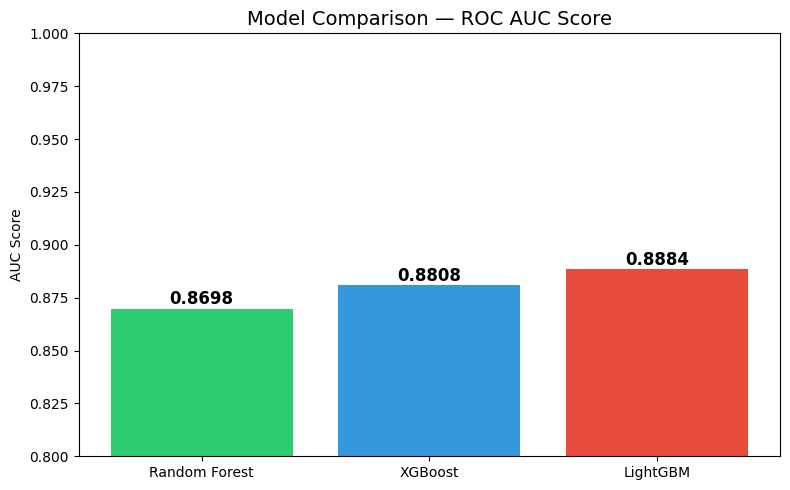

In [8]:
names = list(results.keys())
aucs = [results[n]['auc'] for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, aucs, color=['#2ecc71', '#3498db', '#e74c3c'])
plt.ylim(0.8, 1.0)
plt.title('Model Comparison — ROC AUC Score', fontsize=14)
plt.ylabel('AUC Score')
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{auc:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
best_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_name]['model']

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print(f"🏆 Best Model: {best_name} (AUC: {results[best_name]['auc']:.4f})")
print("✅ Model saved!")

🏆 Best Model: LightGBM (AUC: 0.8884)
✅ Model saved!
